# Heart Disease UCI - Exploratory Data Analysis

Dataset: UCI Heart Disease (Cleveland subset, 303 patients, 13 clinical features).
Target collapsed to binary risk: 0 = no disease, 1 = disease present (original `num` severity scale 0-4).

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import load_raw, load_clean_data

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Raw data overview & missing values

In [2]:
raw = load_raw()
print(raw.shape)
raw.info()

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


Columns with missing values:
ca      4
thal    2
dtype: int64


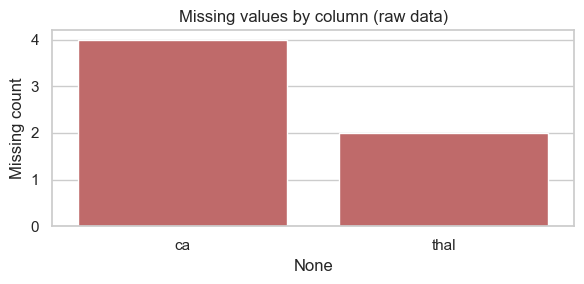

In [3]:
missing = raw.isna().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)

fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(x=missing.index, y=missing.values, ax=ax, color='indianred')
ax.set_title('Missing values by column (raw data)')
ax.set_ylabel('Missing count')
plt.tight_layout()
plt.savefig('../screenshots/eda_missing_values.png', dpi=120)
plt.show()

## 2. Cleaned dataset & target class balance
`ca`/`thal` missing values imputed (median/mode); `num` collapsed to binary `target`.

In [4]:
df = load_clean_data()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


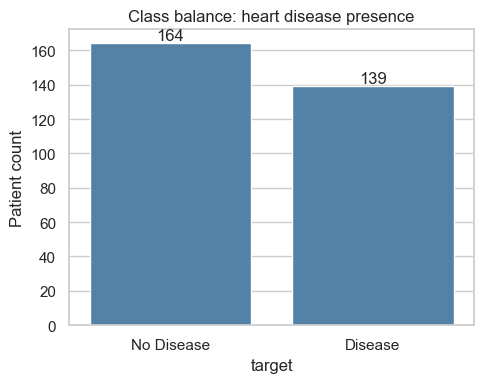

target
0    0.541254
1    0.458746
Name: count, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['target'].value_counts().sort_index()
sns.barplot(x=counts.index.map({0: 'No Disease', 1: 'Disease'}), y=counts.values,
            ax=ax, color='steelblue')
ax.set_title('Class balance: heart disease presence')
ax.set_ylabel('Patient count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha='center')
plt.tight_layout()
plt.savefig('../screenshots/eda_class_balance.png', dpi=120)
plt.show()
print(counts / counts.sum())

## 3. Feature distributions (histograms)

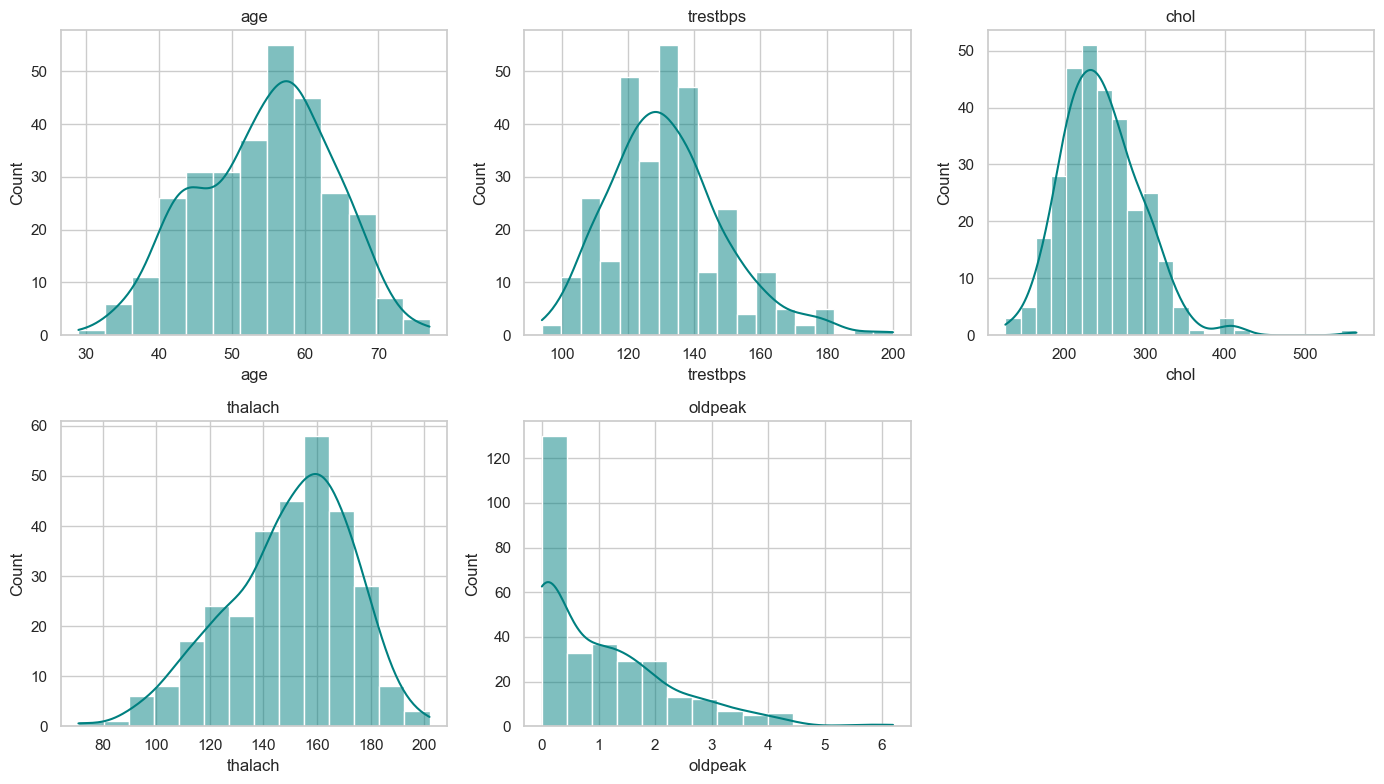

In [6]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='teal')
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('../screenshots/eda_histograms.png', dpi=120)
plt.show()

## 4. Correlation heatmap

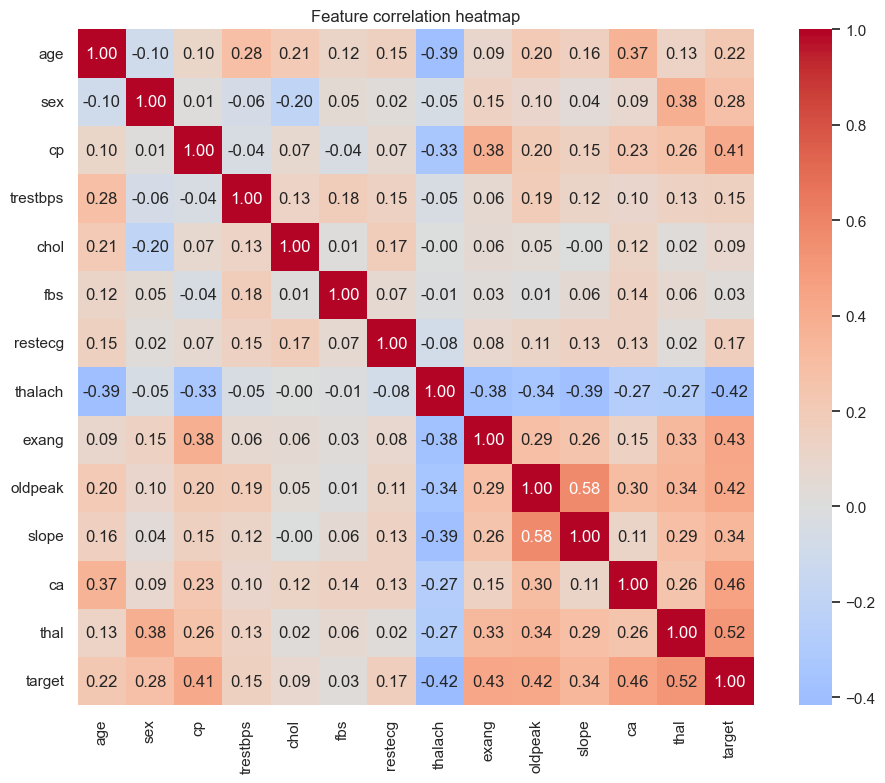

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig('../screenshots/eda_correlation_heatmap.png', dpi=120)
plt.show()

## 5. Feature relationships with target
Focus on the features most correlated with `target` from the heatmap above: `cp` (chest pain type), `thalach` (max heart rate), `oldpeak`, `ca`, `thal`, `exang`.

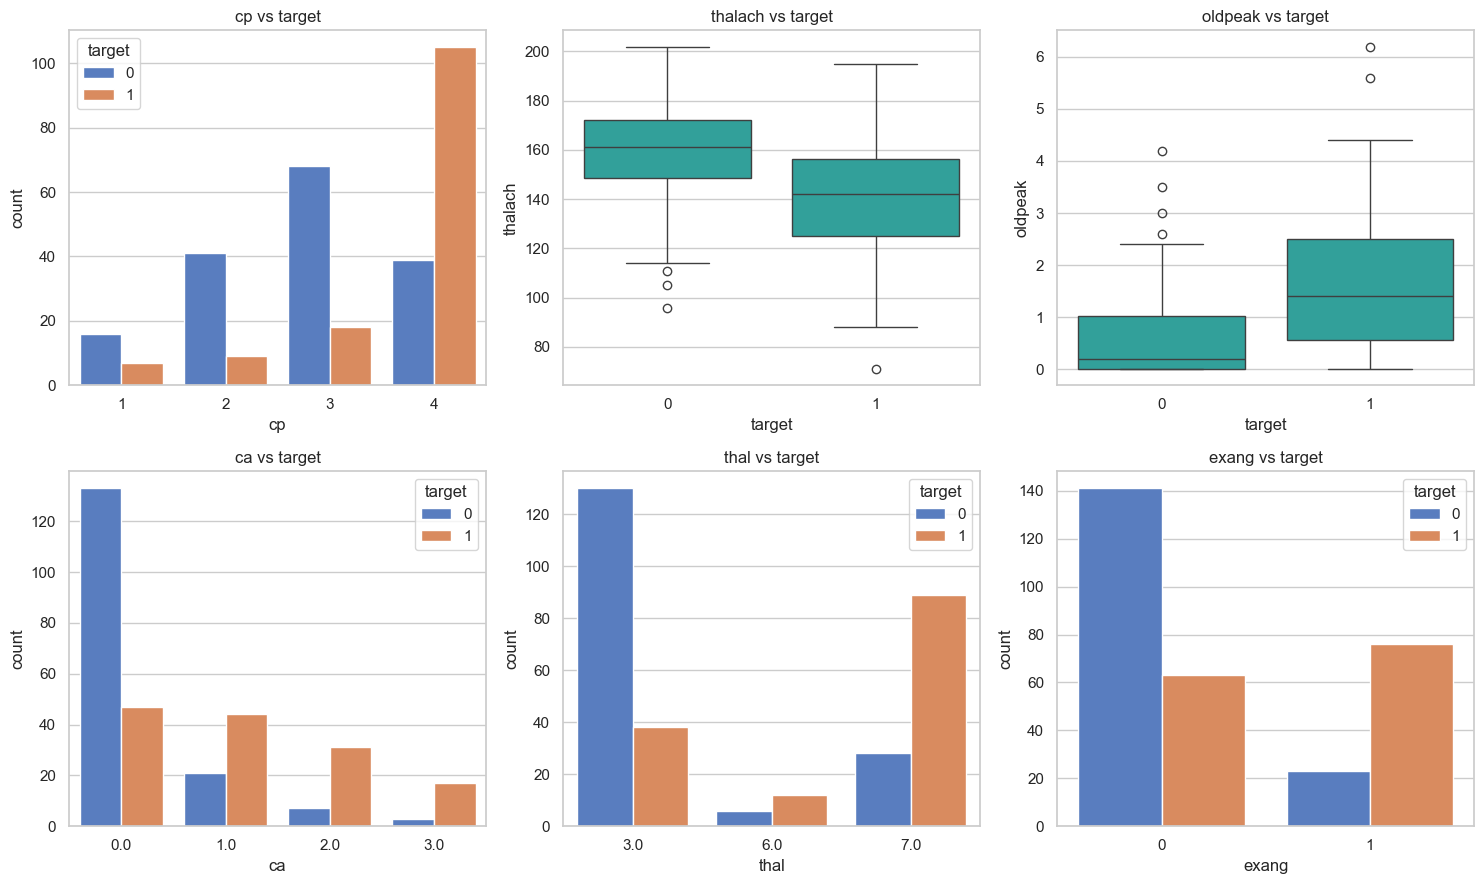

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
focus_cols = ['cp', 'thalach', 'oldpeak', 'ca', 'thal', 'exang']
for ax, col in zip(axes.flat, focus_cols):
    sns.boxplot(data=df, x='target', y=col, ax=ax, color='lightseagreen') if df[col].nunique() > 5 \
        else sns.countplot(data=df, x=col, hue='target', ax=ax)
    ax.set_title(f'{col} vs target')
plt.tight_layout()
plt.savefig('../screenshots/eda_feature_vs_target.png', dpi=120)
plt.show()

## Summary of EDA findings

Dataset: 303 patients, 13 features.

Missing data: ca (4 rows) imputed with median; thal (2 rows) imputed with mode.

Target balance: Binary target (collapsed severity) ~54% no disease, ~46% disease — accuracy is meaningful 
we still track precision, recall, and ROC-AUC.

Top predictors: cp (chest pain type), thalach (max heart rate), oldpeak (ST depression), ca (number of major vessels), and thal :-  these show the strongest separation between classes.

Other features: age, chol, and trestbps show weak individual linear correlation with the target but are retained because they can add non-linear signal (captured well by tree-based models).